<a href="https://colab.research.google.com/github/urshishir6/Credit-Card-Fraud-Detection-Project-1/blob/main/Project1_Credit_Card_Fraud.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Project 1 — Credit Card Fraud Detection
Big Data Analytics and Modeling · Capstone Design Project 1

End-to-end supervised workflow: data acquisition → quality checks → leakage-safe split → EDA (training data only) →
preprocessing pipeline → baseline + 3 models → stratified CV → threshold selection → single held-out test evaluation →
interpretation → error analysis → recommendation.

**Design rules used throughout**
1. The test set is touched **once**, after all modelling decisions (model choice, threshold) are made using training data only.
2. Every learned step (scaler, SMOTE, model) lives **inside a pipeline**, so it is re-fitted inside each CV fold.
3. Every number in a table or figure is computed by the code. Numbers quoted in the written discussion were copied from the outputs of the final run.

| Role | Member |
|---|---|
| Project Manager & Repo Lead | Chaulagai Shishir |
| Data Engineer (Acquisition) | Deula Ritika |
| Data Engineer (Features) | Budhathoki Sandesh |
| Exploratory Data Analyst | Malla Abiraj |
| Validation & Evaluation Lead | KC Hikalpit |
| Modeling Specialist 1 | Rawat Nabraj |
| Modeling Specialist 2 | Thada Magar Mansi |
| Interpretation Analyst | Aayusha Bista |

## 0. Environment, configuration and reproducibility
*Lead: Chaulagai Shishir*

In [1]:
# Run once (Colab / fresh environment). Note the correct package name is scikit-learn (not "scikitlearn").
%pip install -q scikit-learn imbalanced-learn xgboost pandas numpy matplotlib seaborn kagglehub

In [2]:
import json
import platform
import random
import shutil
import sys
import time
import urllib.request
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import sklearn
import imblearn
import xgboost
from IPython.display import display

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, average_precision_score, confusion_matrix, f1_score,
                             precision_recall_curve, precision_score, recall_score, roc_auc_score)
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import FunctionTransformer, RobustScaler
from scipy.stats import spearmanr
from xgboost import XGBClassifier

# ---- configuration (single place to change anything) ----
RANDOM_STATE = 42
TEST_SIZE = 0.20
N_SPLITS = 5
N_BOOT = 200            # bootstrap resamples for the PR-AUC confidence interval
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

# ---- folder structure: raw data is kept separate from processed outputs ----
RAW_DIR, PROC_DIR = Path("data/raw"), Path("data/processed")
FIG_DIR, TAB_DIR = Path("outputs/figures"), Path("outputs/tables")
for d in (RAW_DIR, PROC_DIR, FIG_DIR, TAB_DIR):
    d.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110


def save_fig(name):
    plt.tight_layout()
    plt.savefig(FIG_DIR / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()


def save_table(df_, name, index=True):
    df_.to_csv(TAB_DIR / f"{name}.csv", index=index)


env = {"python": sys.version.split()[0], "platform": platform.platform(), "numpy": np.__version__,
       "pandas": pd.__version__, "scikit-learn": sklearn.__version__, "imbalanced-learn": imblearn.__version__,
       "xgboost": xgboost.__version__, "random_state": RANDOM_STATE}
(TAB_DIR / "environment.json").write_text(json.dumps(env, indent=2))
print(json.dumps(env, indent=2))

{
  "python": "3.13.15",
  "platform": "Linux-6.6.122+-x86_64-with-glibc2.39",
  "numpy": "2.1.3",
  "pandas": "2.2.3",
  "scikit-learn": "1.6.1",
  "imbalanced-learn": "0.14.2",
  "xgboost": "3.4.1",
  "random_state": 42
}


## 1. Data acquisition and provenance
*Lead: Deula Ritika*

**Source:** "Credit Card Fraud Detection" (ULB Machine Learning Group & Worldline), Kaggle: `mlg-ulb/creditcardfraud`.
European cardholders, September 2013, two days of transactions. **Copy the exact licence name shown on the Kaggle dataset page into the report** and cite the original authors
(Dal Pozzolo et al., 2015).

**Verified in the final run:** the file has 284,807 rows and 492 frauds, matching the official description.

The loader tries, in order: (1) a local copy in `data/raw/`, (2) the Kaggle API via `kagglehub`, (3) a public Zenodo mirror.
If all fail, download `creditcard.csv` from Kaggle manually and place it in `data/raw/`.
The original notebook relied on one personal GitHub mirror; single third-party mirrors can disappear, so this version does not.

In [3]:
DATA_PATH = RAW_DIR / "creditcard.csv"
ZENODO_URL = "https://zenodo.org/records/7395559/files/creditcard.csv?download=1"


def download(url, dest):
    req = urllib.request.Request(url, headers={"User-Agent": "Mozilla/5.0"})
    with urllib.request.urlopen(req, timeout=180) as r, open(dest, "wb") as f:
        shutil.copyfileobj(r, f)


if not DATA_PATH.exists():
    try:
        import kagglehub
        p = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
        shutil.copy(Path(p) / "creditcard.csv", DATA_PATH)
        print("Loaded via kagglehub.")
    except Exception as e:
        print(f"kagglehub unavailable ({type(e).__name__}); trying Zenodo mirror...")
        try:
            download(ZENODO_URL, DATA_PATH)
            print("Loaded via Zenodo mirror.")
        except Exception as e2:
            if DATA_PATH.exists():
                DATA_PATH.unlink()
            raise FileNotFoundError(
                "Could not download automatically. Download creditcard.csv from "
                "https://www.kaggle.com/datasets/mlg-ulb/creditcardfraud and place it in data/raw/ ."
            ) from e2

raw = pd.read_csv(DATA_PATH)
print("Shape:", raw.shape)
print("Matches the official dataset (284,807 rows, 492 frauds):",
      raw.shape == (284807, 31) and int(raw["Class"].sum()) == 492)

Using Colab cache for faster access to the 'creditcardfraud' dataset.
Loaded via kagglehub.
Shape: (284807, 31)
Matches the official dataset (284,807 rows, 492 frauds): True


## 2. Data dictionary and data-quality audit
*Lead: Deula Ritika*

In [4]:
data_dictionary = pd.DataFrame({
    "Variable": ["Time", "V1–V28", "Amount", "Class"],
    "Type": ["float (seconds)", "float (PCA components)", "float (currency)", "int (0/1)"],
    "Description": [
        "Seconds elapsed since the first transaction in the dataset (spans ~48 h)",
        "Anonymised principal components of the original card/transaction attributes (original meaning is hidden)",
        "Transaction amount",
        "Target: 1 = fraud, 0 = legitimate"],
})
display(data_dictionary)
save_table(data_dictionary, "data_dictionary", index=False)

quality = pd.Series({
    "rows": len(raw),
    "columns": raw.shape[1],
    "missing values (total)": int(raw.isnull().sum().sum()),
    "exact duplicate rows": int(raw.duplicated().sum()),
    "non-numeric columns": int((~raw.dtypes.apply(pd.api.types.is_numeric_dtype)).sum()),
    "negative Amounts": int((raw["Amount"] < 0).sum()),
    "zero Amounts": int((raw["Amount"] == 0).sum()),
}, name="value")
display(quality.to_frame())
display(raw[["Time", "Amount"]].describe().T)

,Variable,Type,Description
0,Time,float (seconds),Seconds elapsed since the first transaction in...
1,V1–V28,float (PCA components),Anonymised principal components of the origina...
2,Amount,float (currency),Transaction amount
3,Class,int (0/1),"Target: 1 = fraud, 0 = legitimate"


,value
rows,284807
columns,31
missing values (total),0
exact duplicate rows,1081
non-numeric columns,0
negative Amounts,0
zero Amounts,1825


,count,mean,std,min,25%,50%,75%,max
Time,284807.0,94813.859575,47488.145955,0.0,54201.5,84692.0,139320.500,172792.00
Amount,284807.0,88.349619,250.120109,0.0,5.6,22.0,77.165,25691.16


**Decision — duplicates.** Exact duplicate rows are removed *before* splitting. Otherwise the same transaction can land
in both train and test, which inflates the test score (a form of leakage). This step is deterministic and learns nothing
from the data, so doing it before the split is safe.

In [5]:
n_before, f_before = len(raw), int(raw["Class"].sum())
df = raw.drop_duplicates().reset_index(drop=True)
print(f"Rows: {n_before:,} -> {len(df):,}  (removed {n_before - len(df):,}); "
      f"frauds: {f_before} -> {int(df['Class'].sum())}")

prevalence = df["Class"].mean()
print(f"Fraud prevalence: {prevalence:.4%} | accuracy of 'always legitimate': {1 - prevalence:.4%}")

Rows: 284,807 -> 283,726  (removed 1,081); frauds: 492 -> 473
Fraud prevalence: 0.1667% | accuracy of 'always legitimate': 99.8333%


**Result.** 1,081 exact duplicate rows were removed (19 of them frauds), leaving 283,726 transactions of which 473 are
fraud (0.167 %). There are no missing values and no non-numeric columns. A model that always answers "legitimate" is
99.83 % accurate while detecting no fraud at all, which is why accuracy is not used to judge models in this project.

## 3. Leakage-safe stratified train/test split
*Lead: KC Hikalpit*

The split happens **before** any EDA that informs modelling, scaling, resampling or model fitting.
From here on, EDA uses the training set only; the test set is kept sealed until Section 8.

In [6]:
X = df.drop(columns="Class")
y = df["Class"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, stratify=y, random_state=RANDOM_STATE)

split_summary = pd.DataFrame({
    "rows": [len(X_train), len(X_test)],
    "frauds": [int(y_train.sum()), int(y_test.sum())],
    "fraud rate": [y_train.mean(), y_test.mean()]}, index=["train", "test"])
display(split_summary.style.format({"fraud rate": "{:.4%}"}))
pd.Series(X_train.index, name="row_id").to_csv(PROC_DIR / "train_index.csv", index=False)
pd.Series(X_test.index, name="row_id").to_csv(PROC_DIR / "test_index.csv", index=False)

,rows,frauds,fraud rate
train,226980,378,0.1665%
test,56746,95,0.1674%


**Result.** The stratified split gives 226,980 training transactions (378 frauds) and 56,746 test transactions (95 frauds);
both parts keep the same 0.167 % fraud rate. With only 95 test frauds, every test metric is based on a very small
number of events, so differences of one or two frauds are within noise.

## 4. Focused EDA (training data only)
*Lead: Malla Abiraj*

Each plot below answers a modelling question: *(a)* how imbalanced is the target (→ metric and imbalance strategy),
*(b)* is `Amount` skewed (→ scaling), *(c, d)* does `Time` carry usable signal and is it cyclic (→ feature engineering),
and which `V` features separate the classes (→ what to expect from interpretation).

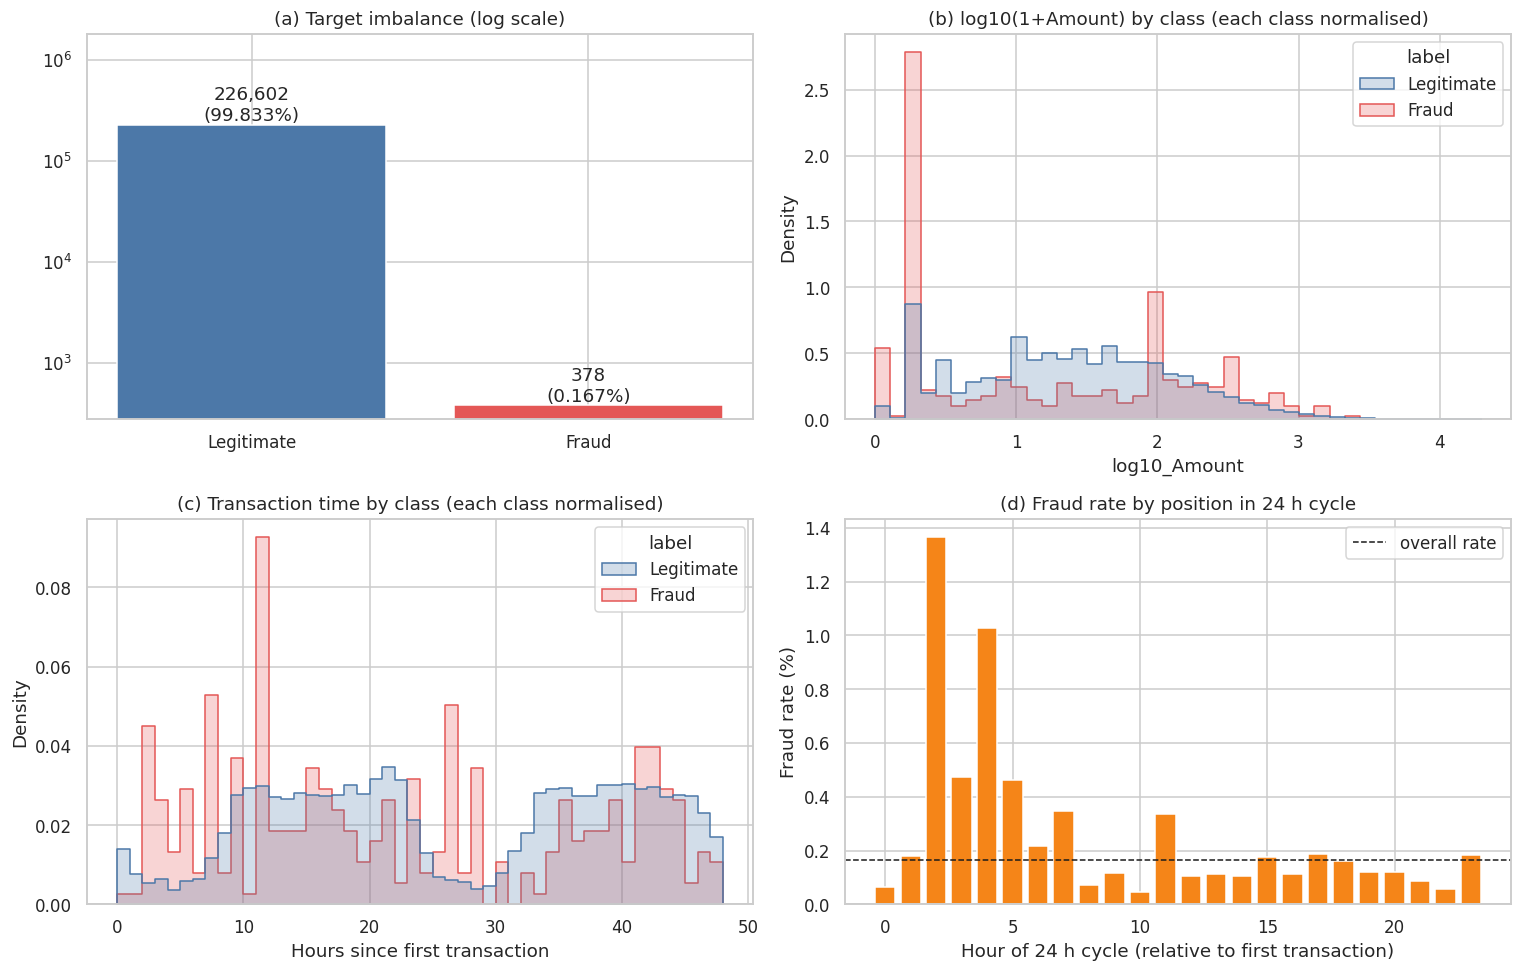

,count,mean,std,min,50%,90%,99%,max
label,,,,,,,,
Fraud,378.0,115.939365,245.552747,0.0,9.555,329.246,1347.5488,2125.87
Legitimate,226602.0,88.341164,245.765364,0.0,22.080,204.000,1015.6991,19656.53


In [7]:
eda = X_train.copy()
eda["Class"] = y_train
eda["log10_Amount"] = np.log10(1 + eda["Amount"])
eda["hour_cycle"] = ((eda["Time"] // 3600) % 24).astype(int)   # position in a 24 h cycle, relative to first transaction
eda["label"] = eda["Class"].map({0: "Legitimate", 1: "Fraud"})
palette = {"Legitimate": "#4C78A8", "Fraud": "#E45756"}

fig, ax = plt.subplots(2, 2, figsize=(14, 9))

counts = eda["label"].value_counts().reindex(["Legitimate", "Fraud"])
ax[0, 0].bar(counts.index, counts.values, color=[palette[k] for k in counts.index])
ax[0, 0].set_yscale("log")
for i, v in enumerate(counts.values):
    ax[0, 0].text(i, v, f"{v:,}\n({v / counts.sum():.3%})", ha="center", va="bottom")
ax[0, 0].set_title("(a) Target imbalance (log scale)")
ax[0, 0].set_ylim(top=counts.max() * 8)

sns.histplot(data=eda, x="log10_Amount", hue="label", stat="density", common_norm=False, bins=40,
             palette=palette, element="step", ax=ax[0, 1])
ax[0, 1].set_title("(b) log10(1+Amount) by class (each class normalised)")

sns.histplot(data=eda, x=eda["Time"] / 3600, hue="label", stat="density", common_norm=False, bins=48,
             palette=palette, element="step", ax=ax[1, 0])
ax[1, 0].set_xlabel("Hours since first transaction")
ax[1, 0].set_title("(c) Transaction time by class (each class normalised)")

rate = eda.groupby("hour_cycle")["Class"].agg(["mean", "sum", "count"])
ax[1, 1].bar(rate.index, rate["mean"] * 100, color="#F58518")
ax[1, 1].axhline(eda["Class"].mean() * 100, color="k", ls="--", lw=1, label="overall rate")
ax[1, 1].set_xlabel("Hour of 24 h cycle (relative to first transaction)")
ax[1, 1].set_ylabel("Fraud rate (%)")
ax[1, 1].set_title("(d) Fraud rate by position in 24 h cycle")
ax[1, 1].legend()
save_fig("eda_overview")

amount_by_class = eda.groupby("label")["Amount"].describe(percentiles=[.5, .9, .99])
display(amount_by_class)
save_table(amount_by_class, "eda_amount_by_class")

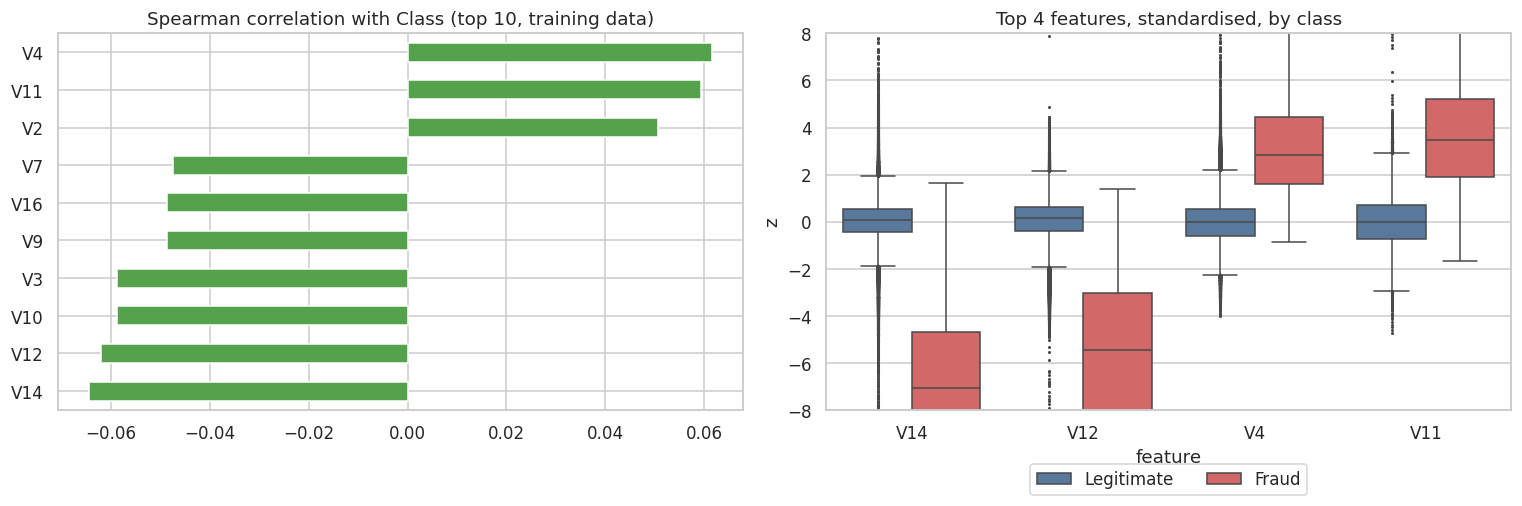

In [8]:
vcols = [f"V{i}" for i in range(1, 29)]
corr = eda[vcols + ["Amount", "Class"]].corr(method="spearman")["Class"].drop("Class")
top = corr.abs().sort_values(ascending=False).head(10).index

fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))
corr.loc[top].sort_values().plot.barh(ax=ax[0], color="#54A24B")
ax[0].set_title("Spearman correlation with Class (top 10, training data)")
melt = eda.melt(id_vars="label", value_vars=list(top[:4]), var_name="feature")
melt["z"] = melt.groupby("feature")["value"].transform(lambda s: (s - s.mean()) / s.std())
sns.boxplot(data=melt, x="feature", y="z", hue="label", palette=palette, fliersize=1, ax=ax[1])
ax[1].set_ylim(-8, 8)
ax[1].set_title("Top 4 features, standardised, by class")
sns.move_legend(ax[1], "upper center", bbox_to_anchor=(0.5, -0.12), ncol=2, title=None)
save_fig("eda_features")
save_table(corr.rename("spearman_with_class").to_frame(), "eda_feature_correlations")

### EDA findings (training data, 378 frauds)

* **(a) Imbalance.** Frauds are 0.167 % of training transactions (378 of 226,980).
* **(b) Amount.** Fraud has a lower *median* amount than legitimate transactions (about $9.6 vs $22.1) but a higher
  *mean* (about $115.9 vs $88.3), so fraud is a mix of many small and a few large amounts. The legitimate maximum is
  about $19,657, the fraud maximum about $2,126. The fraud histogram shows spikes near $1 and near $100; repeated
  round amounts are a common fraud pattern, but with this data that is a hypothesis, not a proven cause.
* **(c, d) Time.** Legitimate traffic has a clear day/night rhythm (quiet periods in roughly the first 7 hours and again
  around hours 24–31 after the first transaction), while fraud does not dip in those quiet periods. As a result the
  fraud *rate* peaks in the early part of the 24 h cycle, at about 1.4 % around hour 2 and about 1.0 % around hour 4,
  roughly 6–8 times the overall rate. Each hourly bucket contains few frauds, and the "hour" is relative to the first
  transaction, not a known clock time, so this is a pattern to model, not a rule to state as fact.
* **Features.** Spearman correlations with the class are small (at most about 0.06 in absolute value) because the
  positive class is so rare. They understate the separation shown by the boxplots: for V14, V12, V4 and V11 the median
  fraud transaction lies several standard deviations from the legitimate median. The strongest positive correlations
  are V4, V11, V2; the strongest negative are V14, V12, V10.

| Observation | Modelling decision |
|---|---|
| 0.167 % fraud | Accuracy is meaningless: use PR-AUC (primary), precision, recall, F1; stratified folds; SMOTE or class weights *inside* the pipeline |
| Amount is heavily right-skewed with large outliers | `RobustScaler` (median/IQR), fitted on training folds only |
| Fraud rate varies over the 24 h cycle; raw seconds will not generalise to a new day | Replace `Time` with a cyclic encoding (`Time_sin`, `Time_cos`) |
| A few V features (V14, V12, V4, V11) separate the classes clearly | Expect them to dominate interpretation; cross-check methods in Section 9 |

## 5. Preprocessing pipeline
*Lead: Budhathoki Sandesh*

* `Time` → `Time_sin`, `Time_cos` (24 h cycle). Raw `Time` is dropped.
* `Amount` → `RobustScaler`.
* `V1…V28` → passed through (already PCA outputs).

The preprocessor is a **pipeline step**, so inside cross-validation it is re-fitted on each training fold and only
*applied* to the validation fold.

In [9]:
def add_time_features(frame):
    out = frame.copy()
    secs = out["Time"] % 86400
    out["Time_sin"] = np.sin(2 * np.pi * secs / 86400)
    out["Time_cos"] = np.cos(2 * np.pi * secs / 86400)
    return out.drop(columns="Time")


def make_prep_steps():
    """Flat list of preprocessing steps (imblearn pipelines do not accept a nested Pipeline as a step)."""
    return [
        ("time", FunctionTransformer(add_time_features)),
        ("scale", ColumnTransformer([("amount", RobustScaler(), ["Amount"])],
                                    remainder="passthrough", verbose_feature_names_out=False)
         .set_output(transform="pandas")),
    ]


def apply_prep(fitted_pipe, frame):
    """Apply the already-fitted preprocessing steps of a fitted pipeline (no refitting)."""
    out = fitted_pipe.named_steps["time"].transform(frame)
    return fitted_pipe.named_steps["scale"].transform(out)


# sanity check on a throw-away copy: shapes/columns only
_t = Pipeline(make_prep_steps()).fit(X_train)
FEATURE_NAMES = list(_t.transform(X_train.head(3)).columns)
print(len(FEATURE_NAMES), "model features:", FEATURE_NAMES[:3], "...", FEATURE_NAMES[-3:])

31 model features: ['Amount', 'V1', 'V2'] ... ['V28', 'Time_sin', 'Time_cos']


## 6. Baseline and candidate models
*Leads: Rawat Nabraj (baseline, Logistic Regression) & Thada Magar Mansi (Random Forest, XGBoost)*

| Model | Role | Imbalance handling |
|---|---|---|
| Majority-class `DummyClassifier` | naive benchmark | — |
| Logistic Regression | simple / interpretable | SMOTE (minority raised to 10 % of majority) **inside the pipeline** |
| Random Forest | stronger alternative | `class_weight="balanced_subsample"` |
| XGBoost | stronger alternative | `scale_pos_weight = n_legit / n_fraud` |

SMOTE is applied only to training folds (imblearn pipelines skip it at predict time). A 10 % target ratio, rather than
full 1:1, is chosen to limit the number of false alarms synthetic oversampling tends to create.
Hyper-parameters are deliberately moderate and fixed: Project 1 does not require tuning.

In [10]:
n_neg, n_pos = int((y_train == 0).sum()), int((y_train == 1).sum())

models = {
    "Naive (majority class)": DummyClassifier(strategy="prior"),
    "Logistic Regression + SMOTE": ImbPipeline([
        *make_prep_steps(),
        ("smote", SMOTE(sampling_strategy=0.1, random_state=RANDOM_STATE)),
        ("clf", LogisticRegression(max_iter=2000, random_state=RANDOM_STATE))]),
    "Random Forest (balanced)": Pipeline([
        *make_prep_steps(),
        ("clf", RandomForestClassifier(n_estimators=100, max_depth=12, min_samples_leaf=2,
                                       class_weight="balanced_subsample", n_jobs=-1,
                                       random_state=RANDOM_STATE))]),
    "XGBoost (scale_pos_weight)": Pipeline([
        *make_prep_steps(),
        ("clf", XGBClassifier(n_estimators=300, max_depth=4, learning_rate=0.1, subsample=0.8,
                              colsample_bytree=0.8, scale_pos_weight=n_neg / n_pos, tree_method="hist",
                              eval_metric="aucpr", n_jobs=-1, random_state=RANDOM_STATE))]),
}
CANDIDATES = [m for m in models if not m.startswith("Naive")]
print("Models:", list(models))

Models: ['Naive (majority class)', 'Logistic Regression + SMOTE', 'Random Forest (balanced)', 'XGBoost (scale_pos_weight)']


## 7. Validation: stratified k-fold CV on the training set
*Lead: KC Hikalpit*

**Why these metrics.** A missed fraud (false negative) costs the issuer money; a false alarm (false positive) costs analyst
time and customer goodwill. Accuracy hides both. **PR-AUC** (average precision) is threshold-free and focuses on the
rare class, so it is the primary model-selection metric; precision, recall and F1 describe the operating point; ROC-AUC
is reported for reference only (it is optimistic under heavy imbalance).

One pass over the folds produces (i) fold-level metrics for model comparison and (ii) **out-of-fold probabilities** that
are later used to choose the decision threshold — all without touching the test set.

In [11]:
skf = StratifiedKFold(n_splits=N_SPLITS, shuffle=True, random_state=RANDOM_STATE)
oof = {name: np.zeros(len(X_train)) for name in models}
rows = []
t0 = time.time()
for name, est in models.items():
    for fold, (tr, va) in enumerate(skf.split(X_train, y_train), start=1):
        t1 = time.time()
        m = clone(est).fit(X_train.iloc[tr], y_train.iloc[tr])
        p = m.predict_proba(X_train.iloc[va])[:, 1]
        yv, pred = y_train.iloc[va], (p >= 0.5).astype(int)
        oof[name][va] = p
        rows.append({"Model": name, "Fold": fold,
                     "PR-AUC": average_precision_score(yv, p), "ROC-AUC": roc_auc_score(yv, p),
                     "Precision@0.5": precision_score(yv, pred, zero_division=0),
                     "Recall@0.5": recall_score(yv, pred, zero_division=0),
                     "F1@0.5": f1_score(yv, pred, zero_division=0), "fit+predict s": time.time() - t1})
    print(f"{name:32s} done ({time.time() - t0:5.0f}s elapsed)")

cv_folds = pd.DataFrame(rows)
metric_cols = ["PR-AUC", "ROC-AUC", "Precision@0.5", "Recall@0.5", "F1@0.5"]
cv_summary = cv_folds.groupby("Model")[metric_cols].agg(["mean", "std"]).loc[list(models)]
cv_summary.columns = [f"{a} {b}" for a, b in cv_summary.columns]
display(cv_summary.style.format("{:.3f}"))
save_table(cv_folds, "cv_fold_metrics", index=False)
save_table(cv_summary, "cv_summary")

# model selection uses CV PR-AUC only (never the test set)
best_name = cv_summary.loc[CANDIDATES, "PR-AUC mean"].idxmax()
print(f"\nBest candidate by mean CV PR-AUC: {best_name}")

Naive (majority class)           done (    0s elapsed)
Logistic Regression + SMOTE      done (   13s elapsed)
Random Forest (balanced)         done (  479s elapsed)
XGBoost (scale_pos_weight)       done (  528s elapsed)


,PR-AUC mean,PR-AUC std,ROC-AUC mean,ROC-AUC std,Precision@0.5 mean,Precision@0.5 std,Recall@0.5 mean,Recall@0.5 std,F1@0.5 mean,F1@0.5 std
Model,,,,,,,,,,
Naive (majority class),0.002,0.000,0.500,0.000,0.000,0.000,0.000,0.000,0.000,0.000
Logistic Regression + SMOTE,0.757,0.026,0.978,0.011,0.416,0.042,0.862,0.033,0.560,0.040
Random Forest (balanced),0.828,0.035,0.964,0.023,0.894,0.039,0.794,0.053,0.840,0.035
XGBoost (scale_pos_weight),0.847,0.035,0.979,0.009,0.891,0.041,0.828,0.052,0.857,0.031



Best candidate by mean CV PR-AUC: XGBoost (scale_pos_weight)


**Result.** XGBoost has the highest mean cross-validated PR-AUC, 0.847 ± 0.035 over 5 folds, and is therefore the selected
model (the test set played no part in this choice; the Logistic Regression and Random Forest fold means are in the
`cv_summary` table above). Training cost differed sharply in the final run: Random Forest took about 7 minutes for the
5 folds, XGBoost about 40 seconds and Logistic Regression + SMOTE about 20 seconds.

### 7.1 Decision threshold from out-of-fold predictions
The default 0.5 cut-off is arbitrary under heavy imbalance. For each candidate the threshold that maximises F1 on the
pooled out-of-fold predictions is chosen — using training data only — and then applied unchanged to the test set.

In [12]:
def best_f1_threshold(y_true, p):
    prec, rec, thr = precision_recall_curve(y_true, p)
    f1 = 2 * prec[:-1] * rec[:-1] / np.clip(prec[:-1] + rec[:-1], 1e-12, None)
    i = int(np.nanargmax(f1))
    return float(thr[i]), float(f1[i])


thresholds = {}
for name in CANDIDATES:
    thr, f1 = best_f1_threshold(y_train, oof[name])
    thresholds[name] = thr
thr_table = pd.Series(thresholds, name="threshold (max OOF F1)").to_frame()
display(thr_table.style.format("{:.3f}"))

,threshold (max OOF F1)
Logistic Regression + SMOTE,0.969
Random Forest (balanced),0.540
XGBoost (scale_pos_weight),0.903


**Result.** The F1-optimal thresholds are far from 0.5 for two models: about 0.97 for Logistic Regression + SMOTE, 0.54
for Random Forest and 0.90 for XGBoost. SMOTE and `scale_pos_weight` push predicted probabilities upward, so the
probabilities are **not calibrated** and should be read as scores, not as real fraud probabilities.

## 8. Final fit and one-time evaluation on the held-out test set
*Lead: KC Hikalpit*

In [13]:
def evaluate(y_true, p, thr):
    pred = (p >= thr).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, pred, labels=[0, 1]).ravel()
    return {"Threshold": thr, "Accuracy": accuracy_score(y_true, pred),
            "Precision": precision_score(y_true, pred, zero_division=0),
            "Recall": recall_score(y_true, pred, zero_division=0),
            "F1": f1_score(y_true, pred, zero_division=0),
            "PR-AUC": average_precision_score(y_true, p), "ROC-AUC": roc_auc_score(y_true, p),
            "TP": tp, "FP": fp, "FN": fn, "TN": tn,
            "Alerts per 10k txns": (tp + fp) / len(y_true) * 1e4}


def bootstrap_pr_auc(y_true, p, n=N_BOOT, seed=RANDOM_STATE):
    rng = np.random.default_rng(seed)
    y_true = np.asarray(y_true)
    pos, neg = np.where(y_true == 1)[0], np.where(y_true == 0)[0]
    vals = []
    for _ in range(n):
        idx = np.concatenate([rng.choice(pos, len(pos)), rng.choice(neg, len(neg))])
        vals.append(average_precision_score(y_true[idx], p[idx]))
    return np.percentile(vals, [2.5, 97.5])


fitted, p_test, res_rows = {}, {}, []
for name, est in models.items():
    fitted[name] = clone(est).fit(X_train, y_train)
    p_test[name] = fitted[name].predict_proba(X_test)[:, 1]
    res_rows.append({"Model": name, "Operating point": "default 0.5", **evaluate(y_test, p_test[name], 0.5)})
    if name in CANDIDATES:
        res_rows.append({"Model": name, "Operating point": "tuned (from CV)",
                         **evaluate(y_test, p_test[name], thresholds[name])})

results = pd.DataFrame(res_rows)
ci = {n: bootstrap_pr_auc(y_test, p_test[n]) for n in CANDIDATES}
results["PR-AUC 95% CI"] = results["Model"].map(
    lambda n: f"[{ci[n][0]:.3f}, {ci[n][1]:.3f}]" if n in ci else "—")
fmt = {c: "{:.3f}" for c in ["Threshold", "Accuracy", "Precision", "Recall", "F1", "PR-AUC", "ROC-AUC"]}
fmt["Alerts per 10k txns"] = "{:.1f}"
print(f"=== TEST-SET RESULTS ({int(y_test.sum())} fraud cases in test; small counts => wide uncertainty) ===")
display(results.style.format(fmt))
save_table(results, "test_results", index=False)

=== TEST-SET RESULTS (95 fraud cases in test; small counts => wide uncertainty) ===


,Model,Operating point,Threshold,Accuracy,Precision,Recall,F1,PR-AUC,ROC-AUC,TP,FP,FN,TN,Alerts per 10k txns,PR-AUC 95% CI
0,Naive (majority class),default 0.5,0.500,0.998,0.000,0.000,0.000,0.002,0.500,0,0,95,56651,0.0,—
1,Logistic Regression + SMOTE,default 0.5,0.500,0.998,0.418,0.800,0.549,0.687,0.968,76,106,19,56545,32.1,"[0.584, 0.788]"
2,Logistic Regression + SMOTE,tuned (from CV),0.969,0.999,0.830,0.768,0.798,0.687,0.968,73,15,22,56636,15.5,"[0.584, 0.788]"
3,Random Forest (balanced),default 0.5,0.500,0.999,0.921,0.737,0.819,0.799,0.962,70,6,25,56645,13.4,"[0.714, 0.869]"
4,Random Forest (balanced),tuned (from CV),0.540,0.999,0.932,0.726,0.817,0.799,0.962,69,5,26,56646,13.0,"[0.714, 0.869]"
5,XGBoost (scale_pos_weight),default 0.5,0.500,0.999,0.884,0.800,0.840,0.817,0.971,76,10,19,56641,15.2,"[0.733, 0.887]"
6,XGBoost (scale_pos_weight),tuned (from CV),0.903,1.000,0.960,0.758,0.847,0.817,0.971,72,3,23,56648,13.2,"[0.733, 0.887]"


**Test-set result at each model's tuned threshold** (95 frauds, 56,746 transactions; counts read from the confusion matrices below)

| Model | Threshold | Caught (TP) | Missed (FN) | False alarms (FP) | Precision | Recall | F1 | Alerts per 10k | Test PR-AUC |
|---|---|---|---|---|---|---|---|---|---|
| Naive (majority class) | – | 0 | 95 | 0 | – | 0.000 | – | 0 | 0.002 |
| Logistic Regression + SMOTE | 0.97 | 73 | 22 | 15 | 0.830 | 0.768 | 0.798 | 15.5 | 0.687 |
| Random Forest (balanced) | 0.54 | 69 | 26 | 5 | 0.932 | 0.726 | 0.817 | 13.0 | 0.799 |
| **XGBoost (scale_pos_weight)** | 0.90 | 72 | 23 | 3 | **0.960** | 0.758 | **0.847** | 13.2 | **0.817** |

* **Baseline.** The naive model has 99.83 % accuracy but zero recall; its PR-AUC (0.002) equals the fraud prevalence, which is
  the floor every real model must beat.
* **XGBoost is best on every headline metric**, but the three real models catch almost the same number of frauds
  (69–73 of 95). The main practical difference is **false alarms**: 3 for XGBoost, 5 for Random Forest, 15 for Logistic Regression.
* **The ranking is not statistically decisive.** XGBoost's test PR-AUC is 0.817 (95 % bootstrap CI 0.733–0.887) and the code
  flags that this interval overlaps with the intervals of both other candidates. Cross-validated PR-AUC (0.847) and test
  PR-AUC (0.817) agree within that interval, which suggests no major over-fitting to the training data.
* **Score separation.** XGBoost's scores are bimodal: about 70 test frauds score close to 1, while a group of frauds scores
  close to 0 (right-hand panel of the first figure below). Frauds are mostly either clearly caught or clearly missed, so the
  threshold is not the main limit on recall.

### 8.1 Precision–recall curves and confusion matrices (tuned operating point)

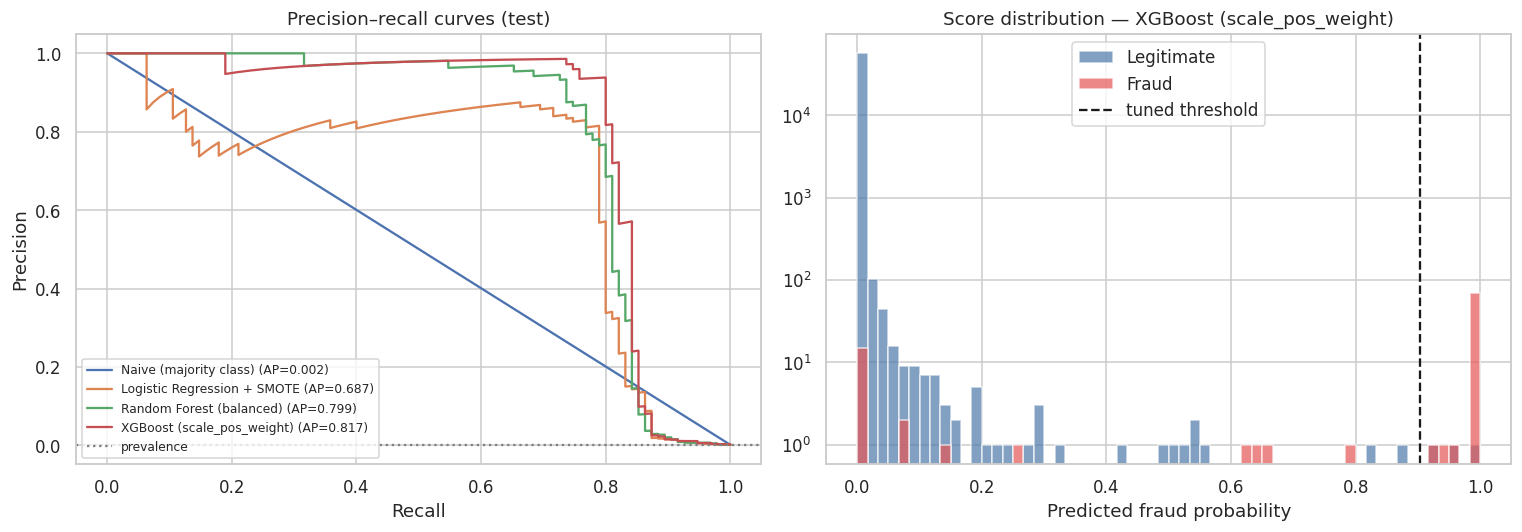

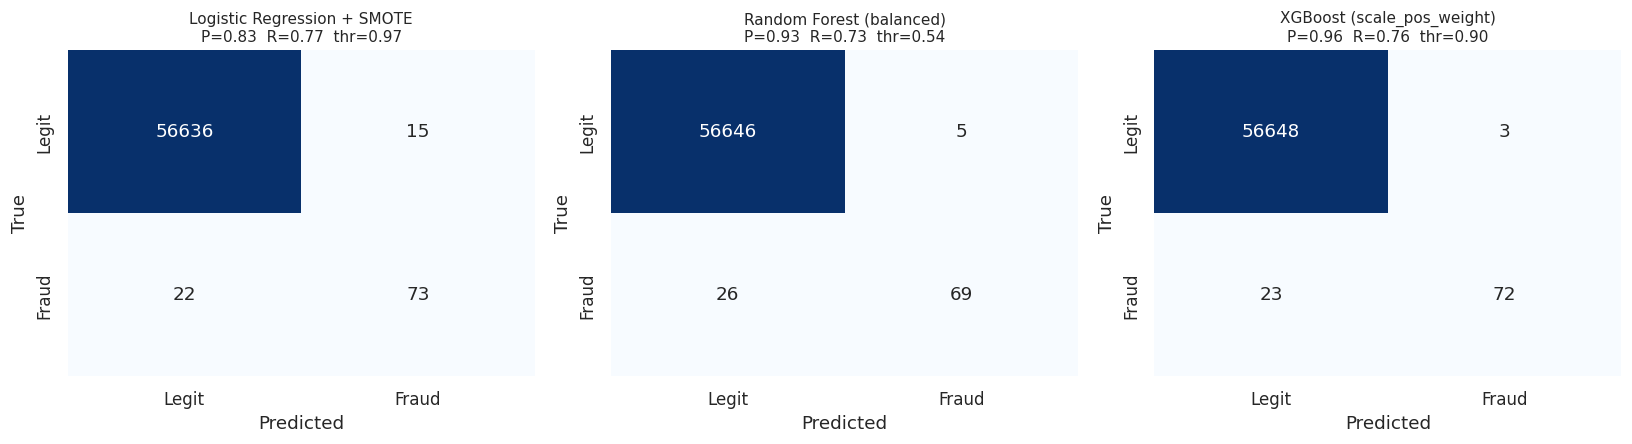

In [14]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for name in models:
    prec, rec, _ = precision_recall_curve(y_test, p_test[name])
    ax[0].plot(rec, prec, label=f"{name} (AP={average_precision_score(y_test, p_test[name]):.3f})")
ax[0].axhline(y_test.mean(), color="gray", ls=":", label="prevalence")
ax[0].set_xlabel("Recall"); ax[0].set_ylabel("Precision"); ax[0].set_title("Precision–recall curves (test)")
ax[0].legend(fontsize=8)

# predicted-probability separation for the selected model
pb = p_test[best_name]
ax[1].hist(pb[y_test == 0], bins=60, alpha=.7, label="Legitimate", color="#4C78A8")
ax[1].hist(pb[y_test == 1], bins=60, alpha=.7, label="Fraud", color="#E45756")
ax[1].axvline(thresholds[best_name], color="k", ls="--", label="tuned threshold")
ax[1].set_yscale("log"); ax[1].set_xlabel("Predicted fraud probability")
ax[1].set_title(f"Score distribution — {best_name}")
ax[1].legend()
save_fig("pr_curves_and_scores")

fig, axes = plt.subplots(1, len(CANDIDATES), figsize=(5 * len(CANDIDATES), 4.2))
for a, name in zip(np.atleast_1d(axes), CANDIDATES):
    r = results[(results.Model == name) & (results["Operating point"] == "tuned (from CV)")].iloc[0]
    cm = np.array([[r.TN, r.FP], [r.FN, r.TP]])
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", cbar=False, ax=a,
                xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"])
    a.set_title(f"{name}\nP={r.Precision:.2f}  R={r.Recall:.2f}  thr={r.Threshold:.2f}", fontsize=10)
    a.set_xlabel("Predicted"); a.set_ylabel("True")
save_fig("confusion_matrices")

## 9. Model interpretation
*Lead: Aayusha Bista*

Three views are compared so that no single method is over-trusted: Logistic-Regression coefficients (simple model),
the selected model's built-in importance, and **permutation importance** (drop in PR-AUC on the test set when one input
is shuffled). All associations are **predictive, not causal**, and the V-features are anonymised PCA components, so they
cannot be translated into real-world attributes such as merchant or location.

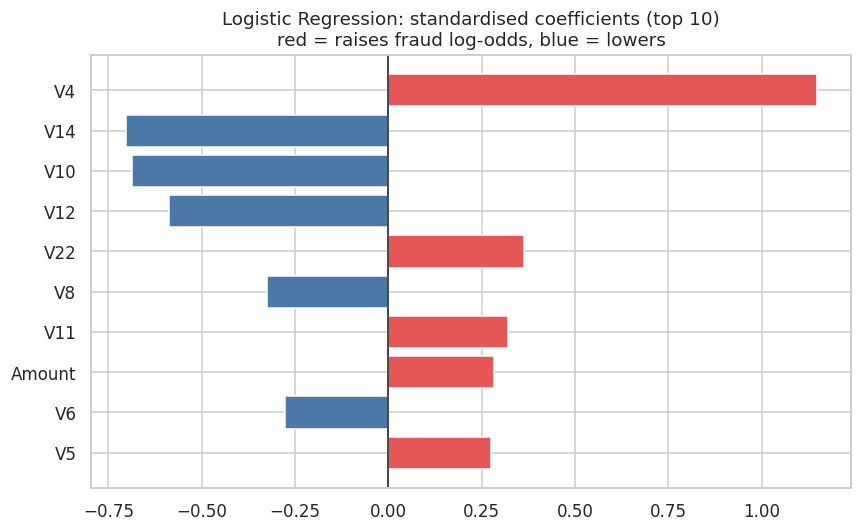

In [15]:
# 9.1 Logistic Regression: coefficient x training std  => effect per one-standard-deviation change
lr_pipe = fitted["Logistic Regression + SMOTE"]
Xt_train = apply_prep(lr_pipe, X_train)
coef = pd.Series(lr_pipe.named_steps["clf"].coef_[0], index=Xt_train.columns)
std_coef = (coef * Xt_train.std()).sort_values(key=np.abs, ascending=False)
top_lr = std_coef.head(10).iloc[::-1]
plt.figure(figsize=(8, 5))
plt.barh(top_lr.index, top_lr.values, color=["#E45756" if v > 0 else "#4C78A8" for v in top_lr.values])
plt.axvline(0, color="k", lw=1)
plt.title("Logistic Regression: standardised coefficients (top 10)\nred = raises fraud log-odds, blue = lowers")
save_fig("interpret_logreg")

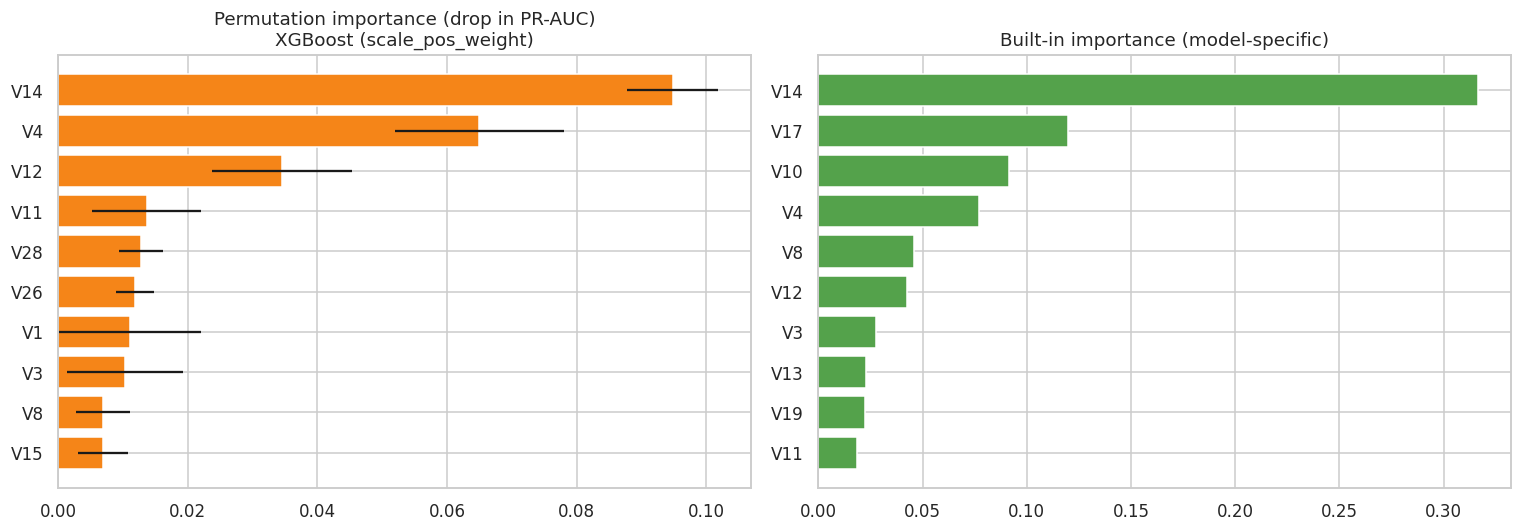

Top-10 overlap, permutation vs built-in: 6 / 10
Features whose permutation reduces PR-AUC by > 1 s.d. -> ['V14', 'V4', 'V12', 'V11', 'V28', 'V26', 'V1', 'V3', 'V8', 'V15']


In [16]:
# 9.2 Selected model: built-in importance vs permutation importance
best_model = fitted[best_name]
perm = permutation_importance(best_model, X_test, y_test, scoring="average_precision",
                              n_repeats=5, random_state=RANDOM_STATE, n_jobs=1)
perm_s = pd.Series(perm.importances_mean, index=X_test.columns).sort_values(ascending=False)
perm_sd = pd.Series(perm.importances_std, index=X_test.columns)[perm_s.index]

clf = best_model.named_steps["clf"]
native = (pd.Series(clf.feature_importances_, index=FEATURE_NAMES) if hasattr(clf, "feature_importances_")
          else pd.Series(np.abs(clf.coef_[0]), index=FEATURE_NAMES))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
t = perm_s.head(10).iloc[::-1]
ax[0].barh(t.index, t.values, xerr=perm_sd[t.index].values, color="#F58518")
ax[0].set_title(f"Permutation importance (drop in PR-AUC)\n{best_name}")
n10 = native.sort_values(ascending=False).head(10).iloc[::-1]
ax[1].barh(n10.index, n10.values, color="#54A24B")
ax[1].set_title("Built-in importance (model-specific)")
save_fig("interpret_selected_model")

top_perm, top_native = set(perm_s.head(10).index), set(native.sort_values(ascending=False).head(10).index)
print("Top-10 overlap, permutation vs built-in:", len(top_perm & top_native), "/ 10")
print("Features whose permutation reduces PR-AUC by > 1 s.d. ->", list(perm_s.index[(perm_s > perm_sd[perm_s.index])][:10]))
save_table(pd.DataFrame({"permutation_mean": perm_s, "permutation_sd": perm_sd}), "permutation_importance")

**Findings.**

* **Logistic Regression.** V4 has the largest standardised coefficient (about +1.15, raises fraud risk); V14, V10 and V12
  follow with negative coefficients of about −0.6 to −0.7 (lower values raise fraud risk). V22, V11, Amount and V5 add smaller
  positive effects; V8 and V6 smaller negative ones.
* **XGBoost, permutation importance** (drop in PR-AUC when a feature is shuffled): V14 is clearly first (about 0.095), then V4
  (about 0.065) and V12 (about 0.035). All other features cause drops of roughly 0.01 or less, and several error bars are
  large, so only the top three are reliable. The engineered `Time_sin`/`Time_cos` features do not appear in the top ten.
* **Agreement between methods.** V14, V4 and V12 appear near the top in every view, which is the most trustworthy result.
  The top-10 lists of permutation and built-in importance overlap in 6 of 10 features. Built-in importance ranks V17 and V10
  second and third, but permutation importance does not. A likely reason is that V10, V12, V14 and V17 are correlated, so
  shuffling one is partly compensated by the others and its permutation score is diluted (a hypothesis the team can check
  with a correlation matrix of these four features).
* **Caution.** These are predictive associations, not causes, and V1–V28 are anonymised PCA components, so none of them can be
  translated into a real-world attribute such as merchant type or location.

## 10. Error analysis
*Lead: Aayusha Bista*

Using the selected model at its tuned threshold: *which* frauds are missed, *which* legitimate transactions are flagged,
and *why might that be?*

In [17]:
thr = thresholds[best_name]
err = X_test.copy()
err["y"], err["proba"] = y_test.values, p_test[best_name]
err["pred"] = (err["proba"] >= thr).astype(int)
err["outcome"] = np.select([(err.y == 1) & (err.pred == 1), (err.y == 0) & (err.pred == 1),
                            (err.y == 1) & (err.pred == 0)], ["TP", "FP", "FN"], default="TN")
print(err["outcome"].value_counts().to_string())

# 10.1 recall and alert volume by transaction amount
bins = [-0.01, 10, 50, 200, 1000, np.inf]
labels = ["<=10", "10-50", "50-200", "200-1000", ">1000"]
err["amount_band"] = pd.cut(err["Amount"], bins=bins, labels=labels)
by_band = err.groupby("amount_band", observed=True).apply(
    lambda g: pd.Series({"transactions": len(g), "frauds": int(g.y.sum()),
                         "caught": int(((g.y == 1) & (g.pred == 1)).sum()),
                         "recall": ((g.y == 1) & (g.pred == 1)).sum() / max(g.y.sum(), 1),
                         "false alarms": int(((g.y == 0) & (g.pred == 1)).sum())}), include_groups=False)
display(by_band.style.format({"recall": "{:.2f}"}))
save_table(by_band, "error_by_amount_band")

outcome
TN    56648
TP       72
FN       23
FP        3


,transactions,frauds,caught,recall,false alarms
amount_band,,,,,
<=10,20176.000000,47.000000,33.000000,0.70,1.000000
10-50,17911.000000,10.000000,9.000000,0.90,1.000000
50-200,12975.000000,18.000000,17.000000,0.94,1.000000
200-1000,5083.000000,17.000000,11.000000,0.65,0.000000
>1000,601.000000,3.000000,2.000000,0.67,0.000000


,V14,V4,V12,V11,V28,V26,Amount
outcome,,,,,,,
TP,-7.21,4.69,-6.15,4.22,0.21,0.06,31.99
FN,-0.93,2.29,-0.34,0.71,0.05,-0.12,3.76
FP,-6.75,3.58,-3.45,2.16,0.30,0.05,10.61
TN,0.06,-0.03,0.14,-0.04,0.01,-0.05,21.60


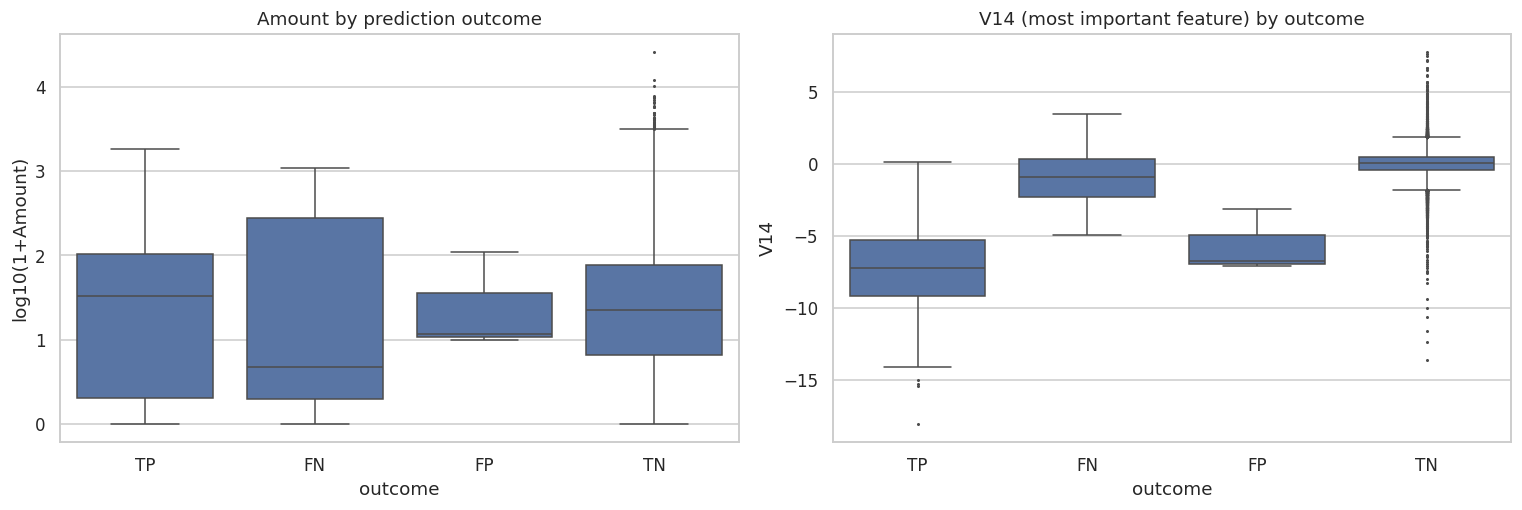


Missed frauds (23), lowest scores first:


,proba,Amount,V14,V4,V12
68371,0.0,1.18,-0.008,0.902,0.687
273358,0.0,0.00,0.984,6.951,-0.050
153692,0.0,0.92,3.442,1.065,-1.472
130779,0.0,0.20,0.521,3.128,0.933
100242,0.0,549.06,0.217,-1.313,-0.005
72475,0.0,1.79,-0.932,0.338,0.044
248322,0.0,1096.99,0.985,0.163,0.980
56464,0.0,0.76,-1.044,0.756,0.655
107830,0.0,0.76,1.028,2.891,-0.869
58516,0.0,1.00,-0.995,1.209,-0.819


In [18]:
# 10.2 Are missed frauds different? Compare medians of the most influential features by outcome
top_feats = [f for f in perm_s.index if f not in ("Time",)][:6]
profile = err.groupby("outcome")[top_feats + ["Amount"]].median().reindex(["TP", "FN", "FP", "TN"])
display(profile.round(2))
save_table(profile, "error_profile_by_outcome")

fig, ax = plt.subplots(1, 2, figsize=(14, 4.8))
sns.boxplot(data=err, x="outcome", y=np.log10(1 + err["Amount"]), order=["TP", "FN", "FP", "TN"], ax=ax[0], fliersize=1)
ax[0].set_ylabel("log10(1+Amount)"); ax[0].set_title("Amount by prediction outcome")
f0 = top_feats[0]
sns.boxplot(data=err, x="outcome", y=f0, order=["TP", "FN", "FP", "TN"], ax=ax[1], fliersize=1)
ax[1].set_title(f"{f0} (most important feature) by outcome")
save_fig("error_analysis")

missed = err[err.outcome == "FN"].sort_values("proba")[["proba", "Amount"] + top_feats[:3]]
print(f"\nMissed frauds ({len(missed)}), lowest scores first:")
display(missed.head(10).round(3))

**Findings (XGBoost at threshold 0.90).** 72 frauds caught, 23 missed, 3 false alarms, 56,648 legitimate transactions passed.

* **Missed frauds look legitimate.** On the key features the median missed fraud is much closer to a normal transaction than
  to a caught fraud: V14 about −0.9 (caught −7.2, legitimate 0.06), V12 about −0.3 (caught −6.2, legitimate 0.14), V11 about
  0.7 (caught 4.2, legitimate −0.04). V4 is intermediate (2.3 vs 4.7 caught vs −0.03 legitimate). The ten lowest-scored missed
  frauds all receive a score of about 0.000 and their V14 values lie in the normal range. No threshold change can recover
  them; they would need information that these features do not contain.
* **Missed frauds tend to be small.** The median missed fraud is about $3.8, against about $32 for caught frauds and about $22
  for legitimate transactions. With only 23 misses this is indicative, not conclusive, but it means the money lost to misses
  may be smaller than the miss *count* suggests; a cost-based threshold using Amount would test this.
* **The 3 false alarms look like fraud.** Their V14 values are about −5 to −7, the same range as caught frauds, so they are
  not random mistakes. They may be genuinely unusual legitimate transactions or unlabelled fraud; only an analyst review
  can tell.
* **Amount bands.** The recall-by-amount table above gives the per-band detail; it rests on very few frauds per band, so
  quote it with caution.

## 11. Alternative validation: time-based hold-out *(optional challenge task)*
*Lead: Chaulagai Shishir*

A random split mixes early and late transactions. In production the model predicts the **future**, so we also train on the
earliest 80 % of transactions and test on the latest 20 %, using the same pipeline and the CV-derived threshold.
A large drop compared with Section 8 would indicate sensitivity to time (concept drift) or just high variance from few frauds.

In [19]:
order = X["Time"].sort_values().index
cut = int(len(order) * (1 - TEST_SIZE))
tr_idx, te_idx = order[:cut], order[cut:]
m_time = clone(models[best_name]).fit(X.loc[tr_idx], y.loc[tr_idx])
p_time = m_time.predict_proba(X.loc[te_idx])[:, 1]
time_res = pd.DataFrame([
    {"Validation": "Random stratified split (Section 8)", "Frauds in test": int(y_test.sum()),
     **evaluate(y_test, p_test[best_name], thresholds[best_name])},
    {"Validation": "Time-based split (earliest 80% -> latest 20%)", "Frauds in test": int(y.loc[te_idx].sum()),
     **evaluate(y.loc[te_idx], p_time, thresholds[best_name])},
])[["Validation", "Frauds in test", "Precision", "Recall", "F1", "PR-AUC", "Alerts per 10k txns"]]
display(time_res.style.format({c: "{:.3f}" for c in ["Precision", "Recall", "F1", "PR-AUC"]} | {"Alerts per 10k txns": "{:.1f}"}))
save_table(time_res, "time_based_validation", index=False)

,Validation,Frauds in test,Precision,Recall,F1,PR-AUC,Alerts per 10k txns
0,Random stratified split (Section 8),95,0.960,0.758,0.847,0.817,13.2
1,Time-based split (earliest 80% -> latest 20%),74,0.889,0.757,0.818,0.794,11.1


**Result.** *(Team: copy the two rows of the table above here, e.g. "Under the time-based split, recall changed from … to …
and PR-AUC from … to …, with … frauds in the later 20 % of the data".)* Interpret the change with care: the later 20 % of the
data contains far fewer than 95 frauds, so a large change may reflect small-sample noise as much as concept drift.

## 12. Final recommendation (generated from the results above)

In [20]:
sel = results[(results.Model == best_name) & (results["Operating point"] == "tuned (from CV)")].iloc[0]
lr_row = results[(results.Model == "Logistic Regression + SMOTE") & (results["Operating point"] == "tuned (from CV)")].iloc[0]
naive = results[results.Model.str.startswith("Naive")].iloc[0]

print(f"Selected model (highest mean CV PR-AUC, test set not used for selection): {best_name}")
print(f"  CV PR-AUC: {cv_summary.loc[best_name, 'PR-AUC mean']:.3f} ± {cv_summary.loc[best_name, 'PR-AUC std']:.3f}")
print(f"  Test PR-AUC: {sel['PR-AUC']:.3f}  (95% bootstrap CI {sel['PR-AUC 95% CI']})")
print(f"  At tuned threshold {sel.Threshold:.3f}: precision {sel.Precision:.3f}, recall {sel.Recall:.3f}, F1 {sel.F1:.3f}")
print(f"  Operational load: {sel['Alerts per 10k txns']:.1f} alerts per 10,000 transactions "
      f"({int(sel.TP)} frauds caught, {int(sel.FN)} missed, {int(sel.FP)} false alarms)")
print(f"Naive benchmark: accuracy {naive.Accuracy:.4f} but recall {naive.Recall:.3f}  -> accuracy is not informative here.")
print(f"Simple model (LogReg+SMOTE) at its tuned threshold: PR-AUC {lr_row['PR-AUC']:.3f}, precision {lr_row.Precision:.3f}, recall {lr_row.Recall:.3f}")

others = [n for n in CANDIDATES if n != best_name]
overlap = [n for n in others if ci[n][1] >= ci[best_name][0] and ci[best_name][1] >= ci[n][0]]
if overlap:
    print("\nCaution: the test-set PR-AUC confidence interval of the selected model overlaps with:", overlap,
          "\n-> with so few fraud cases the ranking is not statistically decisive; weigh interpretability,",
          "speed and operating cost as well.")
else:
    print("\nThe selected model's PR-AUC interval does not overlap with the other candidates.")

# save test predictions for reproducibility / dashboard use
pd.DataFrame({"row_id": X_test.index, "y_true": y_test.values,
              **{n: p_test[n] for n in models}}).to_csv(PROC_DIR / "test_predictions.csv", index=False)

Selected model (highest mean CV PR-AUC, test set not used for selection): XGBoost (scale_pos_weight)
  CV PR-AUC: 0.847 ± 0.035
  Test PR-AUC: 0.817  (95% bootstrap CI [0.733, 0.887])
  At tuned threshold 0.903: precision 0.960, recall 0.758, F1 0.847
  Operational load: 13.2 alerts per 10,000 transactions (72 frauds caught, 23 missed, 3 false alarms)
Naive benchmark: accuracy 0.9983 but recall 0.000  -> accuracy is not informative here.
Simple model (LogReg+SMOTE) at its tuned threshold: PR-AUC 0.687, precision 0.830, recall 0.768

Caution: the test-set PR-AUC confidence interval of the selected model overlaps with: ['Logistic Regression + SMOTE', 'Random Forest (balanced)'] 
-> with so few fraud cases the ranking is not statistically decisive; weigh interpretability, speed and operating cost as well.


### Final recommendation

**Use XGBoost (`scale_pos_weight`, threshold 0.90) as a decision-support model.**

* **Why.** It had the highest cross-validated PR-AUC (0.847 ± 0.035), and on the untouched test set the best PR-AUC (0.817),
  precision (0.960) and F1 (0.847). It caught 72 of 95 frauds with only 3 false alarms, about 13 alerts per 10,000
  transactions, which is a manageable workload for a human review team. It trains in well under a minute, far faster than
  the Random Forest.
* **How strong is the evidence?** Moderate. The test-set confidence intervals of the three real models overlap, and the models
  differ by only a few caught frauds. What is clear is that all three beat the naive baseline by a wide margin and that
  XGBoost and Random Forest produce far fewer false alarms than Logistic Regression.
* **Trade-off.** If regulators or customers need simple explanations, Logistic Regression + SMOTE is a defensible alternative:
  it catches about as many frauds (73) but raises about five times as many false alarms (15 vs 3).
* **Not solved.** About one fraud in four (23 of 95) is missed with scores near zero, so the model must be combined with other
  controls (rules, customer alerts, chargeback monitoring).

### Limitations and responsible use

* **Anonymised features.** V1–V28 are PCA outputs; findings cannot be mapped to real-world attributes, which limits
  explainability to customers and regulators.
* **Very few positives.** The test set holds only 95 frauds, so metrics are noisy; the bootstrap interval quantifies, but does
  not remove, this uncertainty.
* **Single short period.** The data cover two days in September 2013 from European cardholders; fraud patterns drift, so
  performance on today's traffic, other regions or other card types is unknown. Periodic re-training and monitoring would
  be required.
* **Uncalibrated scores and a business threshold.** The 0.90 cut-off maximises F1 on training-fold predictions and treats a
  missed fraud and a false alarm as equally costly. Real deployment should choose the threshold from the issuer's actual
  costs and may use Amount in that cost.
* **False positives harm customers.** Use the model to flag transactions for a human analyst or a step-up verification, not for
  automatic card blocking.
* **Fairness/privacy.** The dataset carries no demographic attributes, so subgroup fairness cannot be assessed here; this must
  be audited before real use.
* **Duplicate handling.** 1,081 duplicate rows (19 frauds) were removed; if duplicates are genuine repeated transactions in
  the issuer's data, this choice should be revisited.

### AI-use statement
Generative AI was used to review the notebook structure, suggest leakage-safe pipeline design and improve training.
All code was run on the actual data, outputs were checked by the team, and no metric was entered manually.
Dataset: Dal Pozzolo, A. et al. (2015), *Calibrating probability with undersampling for unbalanced classification*, IEEE CIDM;
Kaggle `mlg-ulb/creditcardfraud`.
